In [97]:
# Date and time range filter - adjust these knobs to change the plotting window
START_DATE = '2026-01-26'  # Format: 'YYYY-MM-DD'
END_DATE = '2026-01-27'    # Format: 'YYYY-MM-DD'

# Time range within those dates (24-hour format, in HHMM)
START_TIME = '2200'  # Format: 'HHMM' (e.g., '0830' for 8:30 AM, '1400' for 2:00 PM)
END_TIME = '0030'    # Format: 'HHMM' (e.g., '1730' for 5:30 PM, '2359' for 11:59 PM)

# Optional event of concern timestamp (set to None if no event to mark)
# Format: 'MMDDHHMMSS' where year is always 2026 (e.g., '0127001140' = Jan 27 at 00:11:40)
# EVENT_OF_CONCERN = None  # Set to timestamp string like '0127001140' to mark on all plots
EVENT_OF_CONCERN = "0127001140"

In [102]:
# Import core libraries first
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

# Convert HHMM strings to timestamps
_start_hour = int(START_TIME[:2])
_start_min = int(START_TIME[2:4])
_end_hour = int(END_TIME[:2])
_end_min = int(END_TIME[2:4])

PLOT_START = pd.Timestamp(f"{START_DATE} {_start_hour:02d}:{_start_min:02d}:00")
PLOT_END = pd.Timestamp(f"{END_DATE} {_end_hour:02d}:{_end_min:02d}:59")

# Parse event of concern if defined
EVENT_MARKER = None
if EVENT_OF_CONCERN is not None:
    mm = EVENT_OF_CONCERN[0:2]
    dd = EVENT_OF_CONCERN[2:4]
    hh = EVENT_OF_CONCERN[4:6]
    mm_min = EVENT_OF_CONCERN[6:8]
    ss = EVENT_OF_CONCERN[8:10]
    EVENT_MARKER = pd.Timestamp(f"2026-{mm}-{dd} {hh}:{mm_min}:{ss}")
    print(f"Event of concern marked at: {EVENT_MARKER}")

print(f"Plotting range: {PLOT_START} to {PLOT_END}")

# PV mapping and helper functions
pv_mapping = [
    # --- Vacuum Pressure Sensors ---
    ("VALCCG:D04_L01:PRES", "VAC_D4L01"),
    ("VALCCG:D04_L02:PRES", "VAC_D4L02"),
    ("VALCCG:D04_L03:PRES", "VAC_D4L03"),
    ("VALCCG:D04_L04:PRES", "VAC_D4L04"),
    ("VALCCG:D04_L05:PRES", "VAC_D4L05"),
    ("VALCCG:D04_L06:PRES", "VAC_D4L06"),
    ("VALCCG:D04_L07:PRES", "VAC_D4L07"),
    ("VALCCG:D04_L08:PRES", "VAC_D4L08"),
    ("VALCCG:D10_L01:PRES", "VAC_D10L01"),
    ("VALCCG:D10_L02:PRES", "VAC_D10L02"),
    ("VALCCG:D10_L03:PRES", "VAC_D10L03"),
    ("VALCCG:D10_L04:PRES", "VAC_D10L04"),
    ("VALCCG:D10_L05:PRES", "VAC_D10L05"),
    ("VALCCG:D10_L06:PRES", "VAC_D10L06"),
    ("VALCCG:D10_L07:PRES", "VAC_D10L07"),
    ("VALCCG:D10_L08:PRES", "VAC_D10L08"),
    ("VALCCG:D11_L18:PRES", "VAC_D11L18"),
    ("VALCCG:D11_L19:PRES", "VAC_D11L19"),
    ("VALCCG:D11_L20:PRES", "VAC_D11L20"),
    ("VALCCG:D11_L21:PRES", "VAC_D11L21"),
    ("VALCCG:D11_L22:PRES", "VAC_D11L22"),
    ("VALCCG:D11_L23:PRES", "VAC_D11L23"),
    ("VALCCG:D11_L24:PRES", "VAC_D11L24"),

    # --- Radiation and Detectors ---
    ("B2_VXD:Rad:Res:BPATDCU3:A1:DoseRate", "B_DMD_DoseRate"),
    ("B2_VXD:Rad:QCS_FW_225:DoseRate", "B_DMD_QCS_FW_225"),
    ("B2_VXD:Rad:QCS_FW_135:DoseRate", "B_DMD_QCS_FW_135"),
    ("B2_CDC:CUR:LOGGER:L15_2:MAX", "B_CDC_Imax_uA"),
    ("B2_CDC:CUR_AVERAGE", "B_CDC_Iavg_uA"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32", "B_PMThits_Hz"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32_60", "B_PMThits_avg60s"),
    ("B2_nsm:get:TRGOSCILLO0:lff_ler", "B_ECL_BG_duration_ms"),
    ("B2_nsm:get:ECLTRG_FAM:rate_bw", "B_ECL_BW"),

    # ---  Beam Parameters and Injection ---
    ("B2_nsm:get:ECL_LUM_MON:lum_acc_20", "A_LUMI_30"),
    ("CG_OPR:SpecificLuminosity", "A_LUMI_SP_30"),
    ("BMLDCCT:CURRENT", "A_BM_Current_mA"),
    ("BMLDCCT:RATE", "A_BM_Inj_Rate_mAps"),
    ("BMLDCCT:LIFE", "A_BM_Lifetime_min"),
    ("CGLOPT:IP:BETA_Y", "A_BM_BetaY_IP_m"),
    ("CGLOPT:IP:BETA_X", "A_BM_BetaX_IP_m"),
    ("BMLXRM:BEAM:SIGMAX", "A_BM_SigmaX_IP_um"),
    ("BMLXRM:BEAM:SIGMAY", "A_BM_SigmaY_IP_um"),
    ("CG_OPT:CAP:SIGMAY", "A_BM_CapSigmaY_um"),
    ("BTpBPM:QMD11P_K_1:NC_1Hz:C", "A_Qep_BT_end_nC"),
    ("LIiBM:SP_61_8_1:ISNGL:KBP", "A_Qep_Linac_end_nC (?)"),
    ("CGLINJ:EFFICIENCY", "A_INJ_Effi"),
    ("LIiEV:BEAM_REP:READ:KBP", "A_INJ_Rep_ep_Hz"),
    ("CGLINJ:KICKER:HEIGHT_R", "A_INJ_Kicker_Height_mm"),
    ("CGLINJ:KICKER:JUMP_R", "A_INJ_Kicker_Jump"),
    ("CGLINJ:SEPTUM:POS_R", "A_INJ_Septum_Pos_mm"),
    ("CGLINJ:SEPTUM:ANG_R", "A_INJ_Septum_Ang_mm"),
    ("LIIRF:MOPS:SET_PHASE:LER", "A_INJ_Phase"),
    ("CGLINJ:INJECTION:YPOS", "A_INJ_PosY_m"),
    ("CGLINJ:INJECTION:YANG", "A_INJ_AngY_rad"),
    ("BMLD07:INJ:X", "A_INJ_D7_BPMX_mm"),
    ("BMLD07:INJ:Y", "A_INJ_D7_BPMY_mm"),
    ("BMLD07:INJ:Q", "A_INJ_D7_Charge"),
    ("VALCLM:D06CV1TOP:RQ:SET_POS", "A_D6V1_TOP_Head_Pos_Set"),
    ("VALCLM:D06CV1TOP:ST:POS", "A_D6V1_TOP_Head_Pos_Meas"),
    ("VALCLM:D06CV1BTM:RQ:SET_POS", "A_D6V1_BTM_Head_Pos_Set"),
    ("VALCLM:D06CV1BTM:ST:POS", "A_D6V1_BTM_Head_Pos_Meas"),
    ("BML:MQTAFOP1:POS.PXP", "A_D6V1_Upstrm_BPM_PosX"),
    ("BML:MQTAFOP1:POS.PYP", "A_D6V1_Upstrm_BPM_PosY"),
    ("BML:MQT3FOP1:POS.PXP", "A_D6V1_Downstrm_BPM_PosX"),
    ("BML:MQT3FOP1:POS.PYP", "A_D6V1_Downstrm_BPM_PosY")
]

# Create mapping dictionary for fast lookup (case-insensitive)
pv_dict = {k.upper(): v for k, v in pv_mapping}

# Function to get friendly name or return original column name if not found (case-insensitive)
def get_friendly_name(col_name):
    return pv_dict.get(col_name.upper(), col_name)

# Helper to extract original column from safe name used in event columns (case-insensitive)
def get_original_col_from_safe_name(safe_name):
    """Reverse map from safe variable name back to original column name (case-insensitive)"""
    for orig_col in all_numeric_columns if 'all_numeric_columns' in globals() else []:
        safe = orig_col.replace(':', '_').replace('.', '_').replace('-', '_')
        safe = safe.replace('(', '').replace(')', '').replace(' ', '_')
        # Case-insensitive comparison
        if safe.upper() == safe_name.upper():
            return orig_col
    return None

# Function to get friendly name from event-aligned column names (e.g., "acc1_BMLDCCT_CURRENT" -> "acc1_FRIENDLY_NAME")
def get_friendly_name_from_event_col(col_name):
    """Map event-aligned column to friendly name, preserving the prefix (case-insensitive)"""
    parts = col_name.split('_', 1)
    if len(parts) == 2:
        prefix, rest = parts
        # Try to find the original column name
        orig_col = get_original_col_from_safe_name(rest)
        if orig_col:
            friendly = get_friendly_name(orig_col)
            return f"{prefix}_{friendly}"
    return col_name

# Define file paths for all 4 files
acc_file1 = Path('/Users/xylu/Desktop/Data/machine_local/acc/2026-02-03T18_22_22.942Z.csv')
acc_file2 = Path('/Users/xylu/Desktop/Data/machine_local/acc/2026-02-03T18_23_40.600Z.csv')
acc_file3 = Path('/Users/xylu/Desktop/Data/machine_local/acc/2026-02-03T18_23_48.166Z.csv')
belle2_file = Path('/Users/xylu/Desktop/Data/machine_local/belle2/2026-02-03T18_14_05.284Z.csv')
vacuum_file = Path('/Users/xylu/Desktop/Data/machine_local/vacuum/2026-02-03T17_55_43.080Z.csv')

# Read all CSV files with timestamp parsing
acc_df1 = pd.read_csv(acc_file1, parse_dates=['Timestamp'])
acc_df2 = pd.read_csv(acc_file2, parse_dates=['Timestamp'])
acc_df3 = pd.read_csv(acc_file3, parse_dates=['Timestamp'])
belle2_df = pd.read_csv(belle2_file, parse_dates=['Timestamp'])
vacuum_df = pd.read_csv(vacuum_file, parse_dates=['Timestamp'])

# print(f"ACC file 1 shape: {acc_df1.shape}")
# print(f"ACC file 2 shape: {acc_df2.shape}")
# print(f"ACC file 3 shape: {acc_df3.shape}")
# print(f"Belle2 data shape: {belle2_df.shape}")
# print(f"Vacuum data shape: {vacuum_df.shape}")
# print(f"\nACC file 1 columns ({len(acc_df1.columns)}): {list(acc_df1.columns)}")
# print(f"\nACC file 2 columns ({len(acc_df2.columns)}): {list(acc_df2.columns)}")
# print(f"\nACC file 3 columns ({len(acc_df3.columns)}): {list(acc_df3.columns)}")
# print(f"\nBelle2 columns ({len(belle2_df.columns)}): {list(belle2_df.columns)}")
# print(f"\nVacuum columns ({len(vacuum_df.columns)}): {list(vacuum_df.columns)}")

# Save all numeric columns to variables for correlation analysis
acc1_numeric_cols = acc_df1.select_dtypes(include=[np.number]).columns.tolist()
acc2_numeric_cols = acc_df2.select_dtypes(include=[np.number]).columns.tolist()
acc3_numeric_cols = acc_df3.select_dtypes(include=[np.number]).columns.tolist()
belle2_numeric_cols = belle2_df.select_dtypes(include=[np.number]).columns.tolist()
vacuum_numeric_cols = vacuum_df.select_dtypes(include=[np.number]).columns.tolist()

# Combine all data - merge on timestamp with outer join to preserve all data
# First add source column to track origin
acc_df1['source'] = 'ACC1'
acc_df2['source'] = 'ACC2'
acc_df3['source'] = 'ACC3'
belle2_df['source'] = 'Belle2'
vacuum_df['source'] = 'Vacuum'

# Concatenate all dataframes
all_data_list = [acc_df1, acc_df2, acc_df3, belle2_df, vacuum_df]
all_data = pd.concat(all_data_list, axis=0, ignore_index=True, sort=False)

# Save all unique numeric columns (excluding source) - preserve import order
all_numeric_columns = list(dict.fromkeys(acc1_numeric_cols + acc2_numeric_cols + acc3_numeric_cols + belle2_numeric_cols + vacuum_numeric_cols))

# Get min/max dates from all data
all_timestamps = pd.concat([
    acc_df1['Timestamp'],
    acc_df2['Timestamp'],
    acc_df3['Timestamp'],
    belle2_df['Timestamp'],
    vacuum_df['Timestamp']
])

# --- Summary Section ---
print(f"\n--- Summary ---")
print(f"Total rows combined: {len(all_data)}")
print(f"Total unique numeric columns: {len(all_numeric_columns)}")
print(f"Available data range: {all_timestamps.min()} to {all_timestamps.max()}")
print(f"\nAll numeric columns available for correlation analysis (Friendly Names):")

for i, col in enumerate(all_numeric_columns, 1):
    friendly = get_friendly_name(col)
    if friendly != col:
        # Prints: 1. VAC_D4L01 (VALCCG:D04_L01:PRES)
        print(f"  {i:2d}. {friendly} ({col})")
    else:
        # If no mapping exists, just print the original
        print(f"  {i:2d}. {col}")
        
# Save each individual column as a separate variable for easy access
# Create a dictionary to store all columns with their data
columns_dict = {}

# Function to create safe variable names from column names
def safe_var_name(col_name, source):
    # Replace special characters with underscores
    safe_name = col_name.replace(':', '_').replace('.', '_').replace('-', '_')
    safe_name = safe_name.replace('(', '').replace(')', '').replace(' ', '_')
    return f"{source}_{safe_name}"

# Store ACC file 1 columns (use 'acc1' prefix)
for col in acc1_numeric_cols:
    var_name = safe_var_name(col, 'acc1')
    columns_dict[var_name] = acc_df1[col].values
    # Also create the variable in the global namespace
    globals()[var_name] = acc_df1[col].values

# Store ACC file 2 columns (use 'acc2' prefix)
for col in acc2_numeric_cols:
    var_name = safe_var_name(col, 'acc2')
    columns_dict[var_name] = acc_df2[col].values
    globals()[var_name] = acc_df2[col].values

# Store ACC file 3 columns (use 'acc3' prefix)
for col in acc3_numeric_cols:
    var_name = safe_var_name(col, 'acc3')
    columns_dict[var_name] = acc_df3[col].values
    globals()[var_name] = acc_df3[col].values

# Store Belle2 columns
for col in belle2_numeric_cols:
    var_name = safe_var_name(col, 'belle2')
    columns_dict[var_name] = belle2_df[col].values
    globals()[var_name] = belle2_df[col].values

# Store Vacuum columns
for col in vacuum_numeric_cols:
    var_name = safe_var_name(col, 'vacuum')
    columns_dict[var_name] = vacuum_df[col].values
    globals()[var_name] = vacuum_df[col].values


Event of concern marked at: 2026-01-27 00:11:40
Plotting range: 2026-01-26 22:00:00 to 2026-01-27 00:30:59

--- Summary ---
Total rows combined: 79242
Total unique numeric columns: 64
Available data range: 2025-12-20 19:12:09.810000 to 2026-02-03 18:44:43.071000

All numeric columns available for correlation analysis (Friendly Names):
   1. A_LUMI_30 (B2_nsm:get:ECL_LUM_MON:lum_acc_20)
   2. A_LUMI_SP_30 (CG_OPR:SpecificLuminosity)
   3. A_BM_Current_mA (BMLDCCT:CURRENT)
   4. A_BM_BetaY_IP_m (CGLOPT:IP:BETA_Y)
   5. A_BM_BetaX_IP_m (CGLOPT:IP:BETA_X)
   6. A_BM_CapSigmaY_um (CG_OPT:CAP:SIGMAY)
   7. A_Qep_BT_end_nC (BTpBPM:QMD11P_K_1:NC_1Hz:C)
   8. A_Qep_Linac_end_nC (?) (LIiBM:SP_61_8_1:ISNGL:KBP)
   9. A_INJ_Effi (CGLINJ:EFFICIENCY)
  10. A_INJ_Rep_ep_Hz (LIiEV:BEAM_REP:READ:KBP)
  11. A_INJ_Kicker_Height_mm (CGLINJ:KICKER:HEIGHT_R)
  12. A_INJ_Kicker_Jump (CGLINJ:KICKER:JUMP_R)
  13. A_INJ_Septum_Pos_mm (CGLINJ:SEPTUM:POS_R)
  14. A_INJ_Septum_Ang_mm (CGLINJ:SEPTUM:ANG_R)
  15. A_

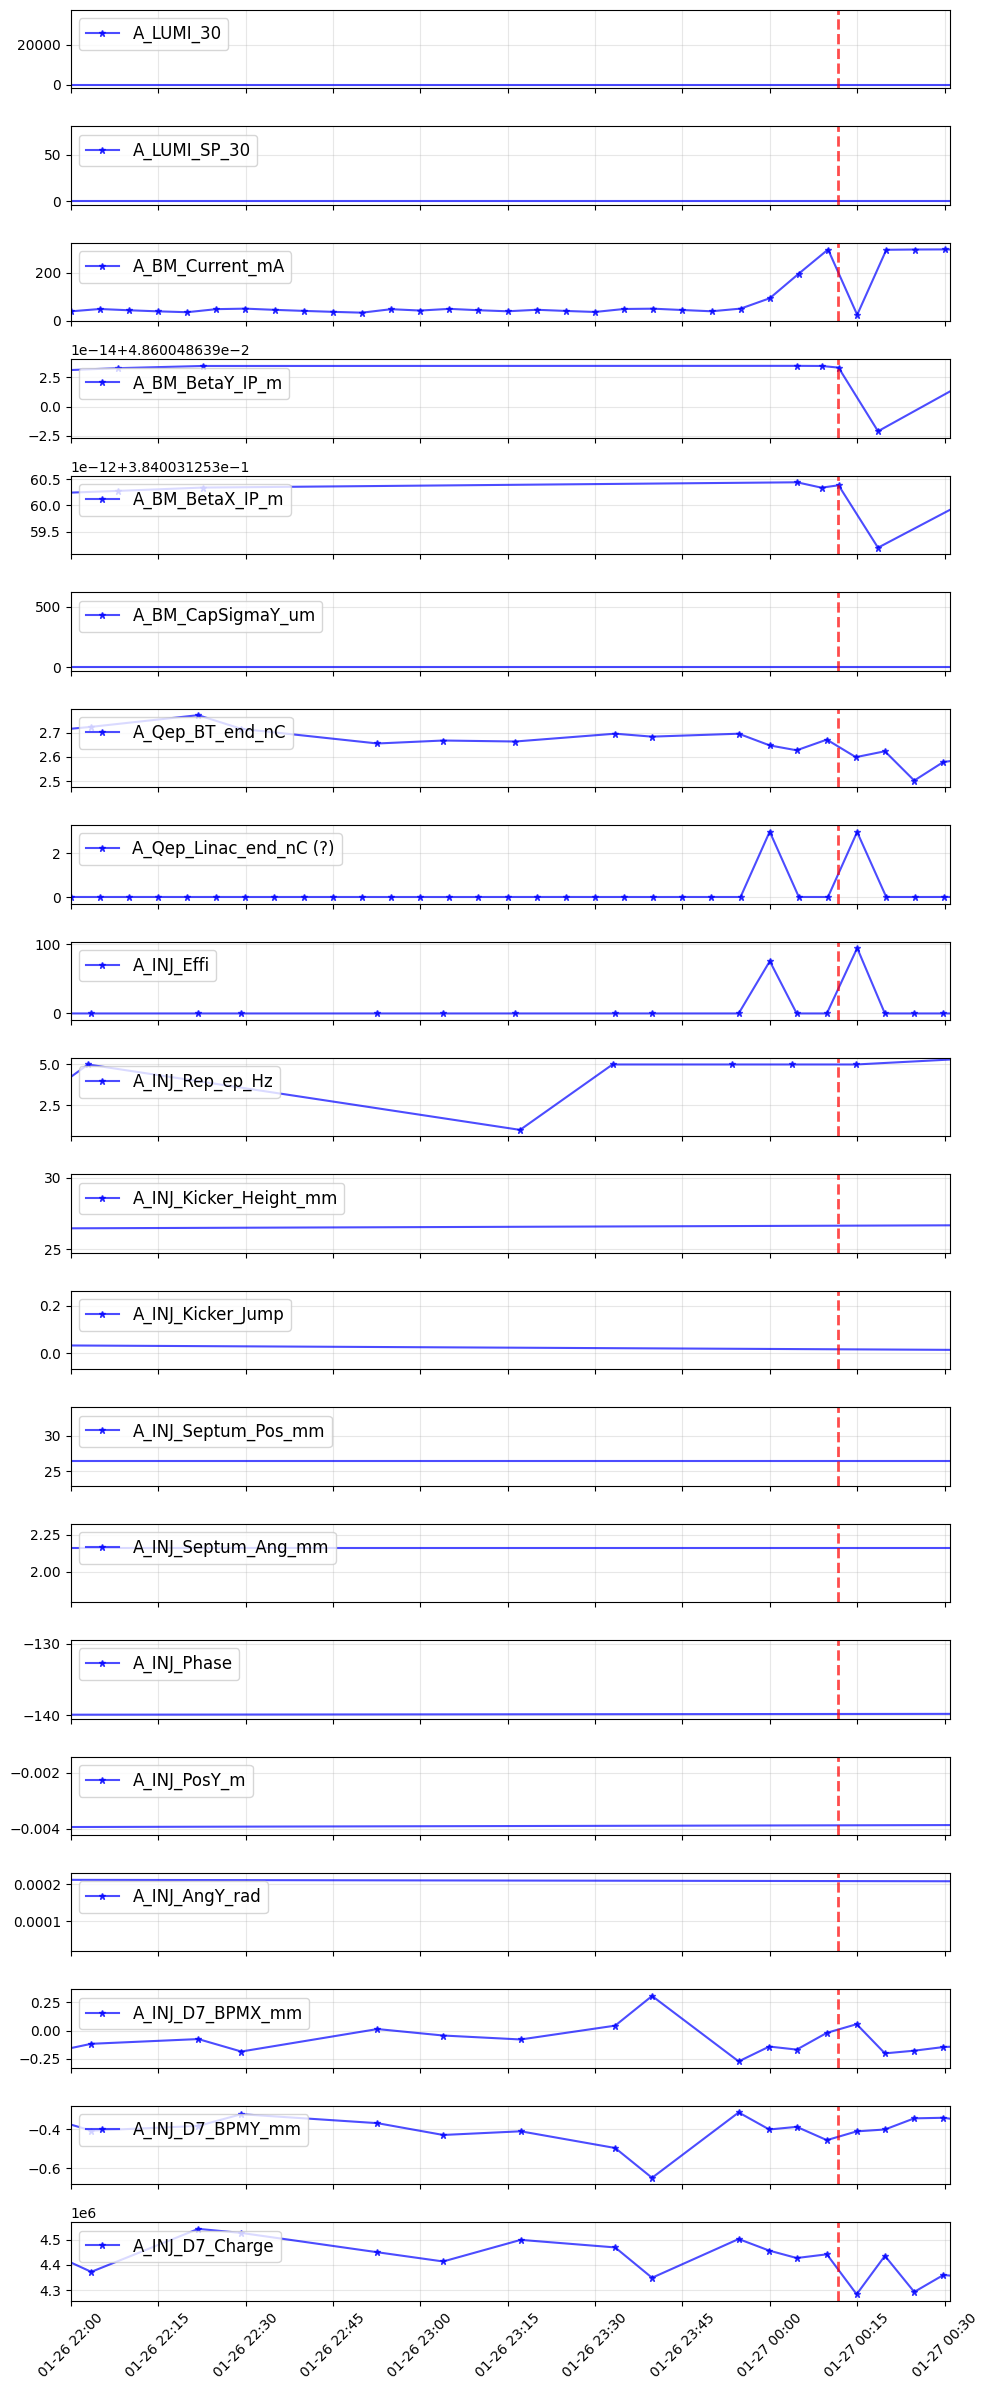

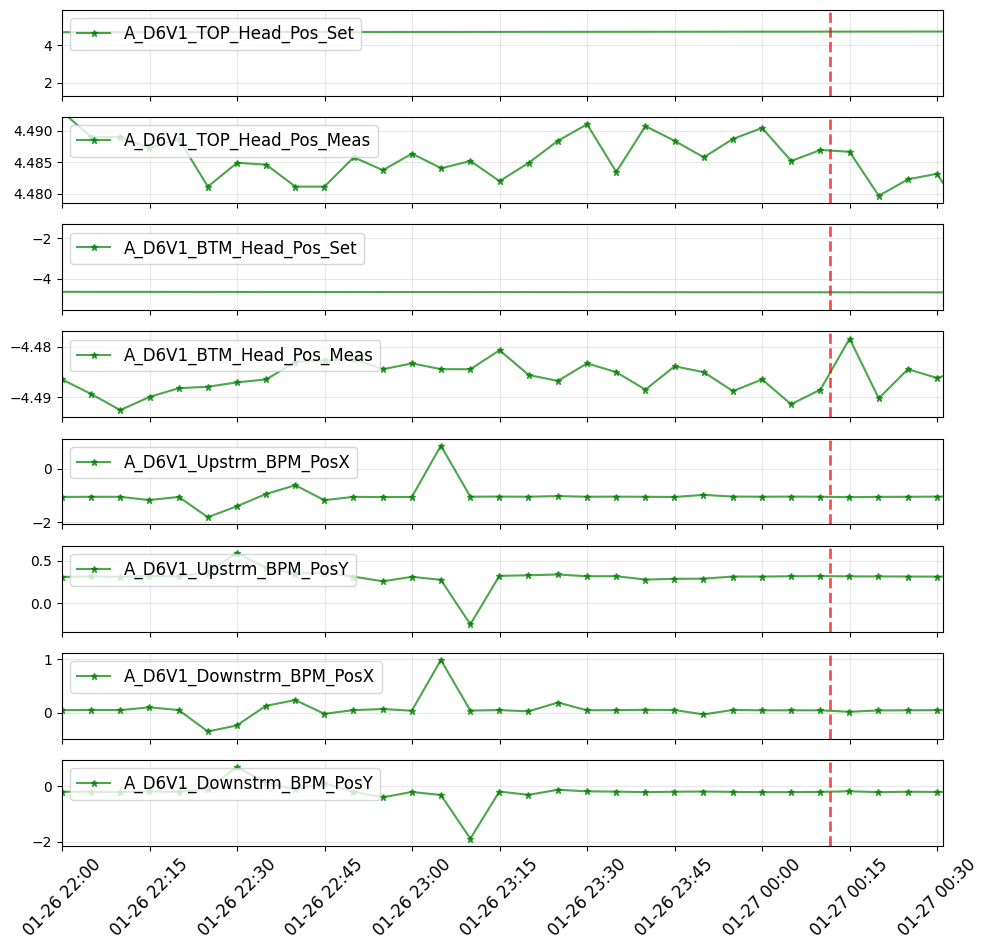

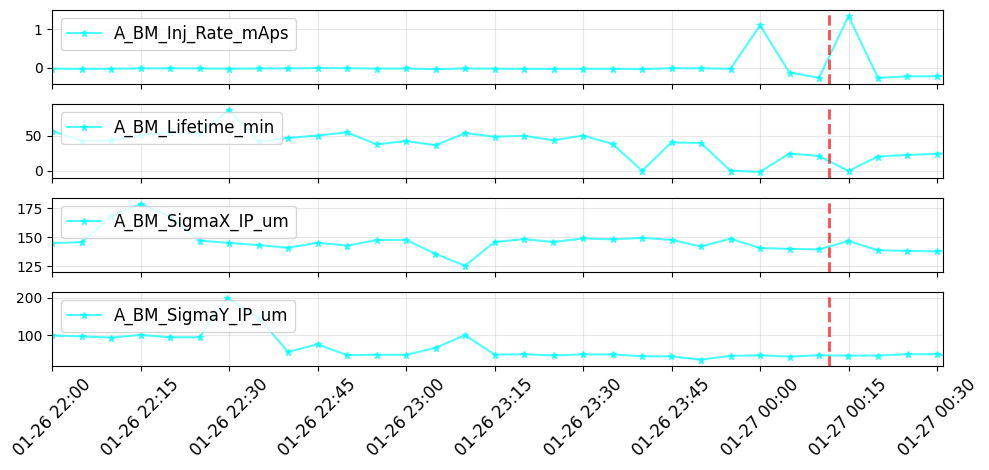

/var/folders/_c/0_qg_9695zvdpz5_56q4wy6w0000gn/T/ipykernel_21014/1173363158.py:120: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes3[i].set_ylim(y_min - y_pad, y_max + y_pad)


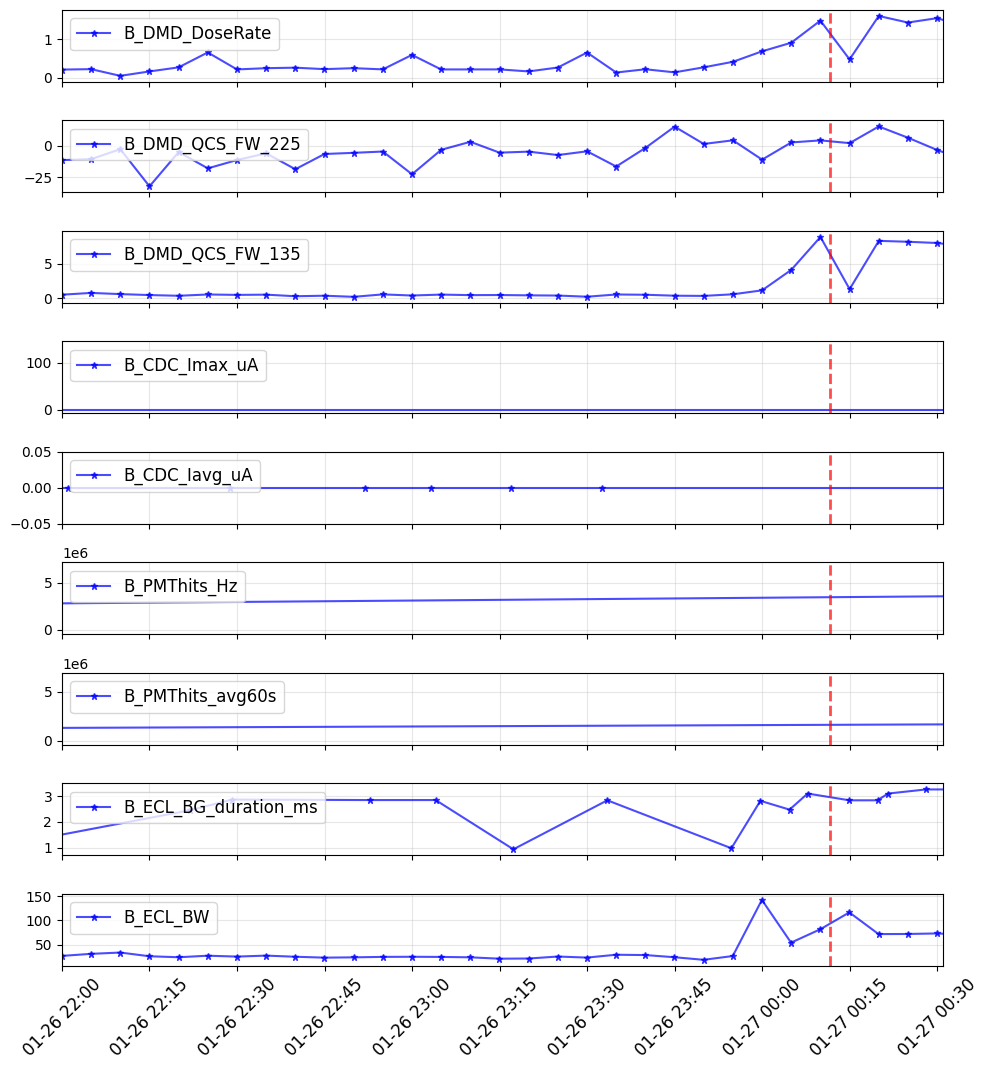

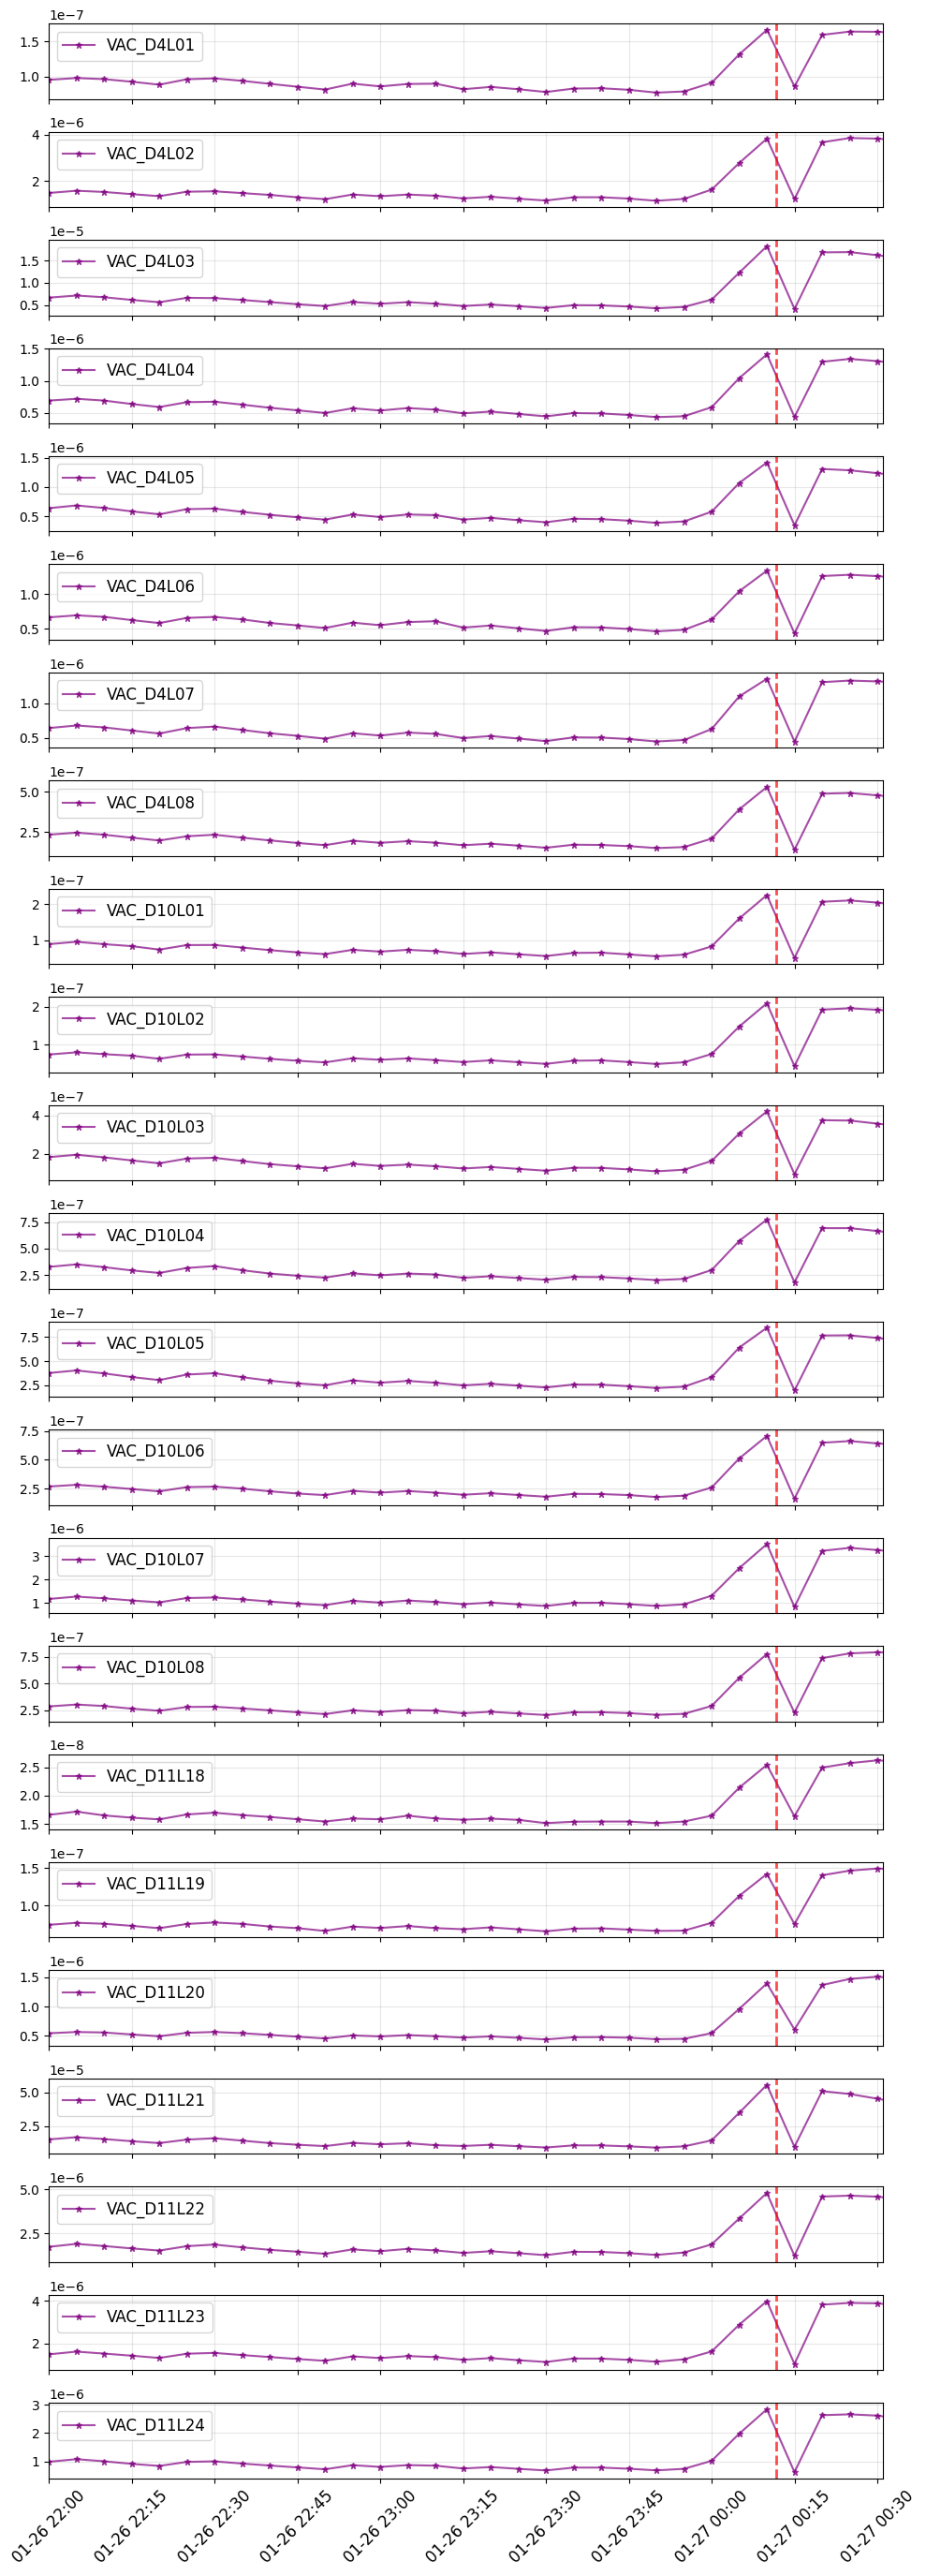

In [103]:
# Create separate figures for each data source with subplots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Figure for ACC1
fig1, axes1 = plt.subplots(len(acc1_numeric_cols), 1, figsize=(10, 1.2*len(acc1_numeric_cols)), sharex=True)
if len(acc1_numeric_cols) == 1:
    axes1 = [axes1]
for i, col in enumerate(acc1_numeric_cols):
    friendly_name = get_friendly_name(col)
    # Remove NaNs but keep line connection through valid points
    valid_mask = acc_df1[col].notna()
    axes1[i].plot(acc_df1.loc[valid_mask, 'Timestamp'], acc_df1.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-', color='blue', label=f'{friendly_name}')
    # Set y-limits based on visible data range
    mask = (acc_df1['Timestamp'] >= PLOT_START) & (acc_df1['Timestamp'] <= PLOT_END)
    if mask.any():
        y_data = acc_df1.loc[mask, col].dropna()
        if len(y_data) > 0:
            y_min, y_max = y_data.min(), y_data.max()
            y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
            axes1[i].set_ylim(y_min - y_pad, y_max + y_pad)
    # axes1[i].set_ylabel('Value', fontsize=12)
    axes1[i].legend(loc='upper left', fontsize=12)
    axes1[i].grid(True, alpha=0.3)
    if i < len(acc1_numeric_cols) - 1:
        axes1[i].set_xlabel('')
axes1[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes1:
    ax.set_xlim(PLOT_START, PLOT_END)
    if EVENT_MARKER is not None:
        ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Event')
plt.xticks(rotation=45, fontsize=10)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
# plt.savefig('acc1_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure for ACC2
fig2, axes2 = plt.subplots(len(acc2_numeric_cols), 1, figsize=(10, 1.2*len(acc2_numeric_cols)), sharex=True)
if len(acc2_numeric_cols) == 1:
    axes2 = [axes2]
for i, col in enumerate(acc2_numeric_cols):
    friendly_name = get_friendly_name(col)
    # Remove NaNs but keep line connection through valid points
    valid_mask = acc_df2[col].notna()
    axes2[i].plot(acc_df2.loc[valid_mask, 'Timestamp'], acc_df2.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-', color='green', label=f'{friendly_name}')
    # Set y-limits based on visible data range
    mask = (acc_df2['Timestamp'] >= PLOT_START) & (acc_df2['Timestamp'] <= PLOT_END)
    if mask.any():
        y_data = acc_df2.loc[mask, col].dropna()
        if len(y_data) > 0:
            y_min, y_max = y_data.min(), y_data.max()
            y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
            axes2[i].set_ylim(y_min - y_pad, y_max + y_pad)
    # axes2[i].set_ylabel('Value', fontsize=12)
    axes2[i].legend(loc='upper left', fontsize=12)
    axes2[i].grid(True, alpha=0.3)
    if i < len(acc2_numeric_cols) - 1:
        axes2[i].set_xlabel('')
axes2[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes2:
    ax.set_xlim(PLOT_START, PLOT_END)
    if EVENT_MARKER is not None:
        ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Event')
plt.xticks(rotation=45, fontsize=12)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
# plt.savefig('acc2_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure for ACC3
fig_acc3, axes_acc3 = plt.subplots(len(acc3_numeric_cols), 1, figsize=(10, 1.2*len(acc3_numeric_cols)), sharex=True)
if len(acc3_numeric_cols) == 1:
    axes_acc3 = [axes_acc3]
for i, col in enumerate(acc3_numeric_cols):
    friendly_name = get_friendly_name(col)
    # Remove NaNs but keep line connection through valid points
    valid_mask = acc_df3[col].notna()
    axes_acc3[i].plot(acc_df3.loc[valid_mask, 'Timestamp'], acc_df3.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-', color='cyan', label=f'{friendly_name}')
    # Set y-limits based on visible data range
    mask = (acc_df3['Timestamp'] >= PLOT_START) & (acc_df3['Timestamp'] <= PLOT_END)
    if mask.any():
        y_data = acc_df3.loc[mask, col].dropna()
        if len(y_data) > 0:
            y_min, y_max = y_data.min(), y_data.max()
            y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
            axes_acc3[i].set_ylim(y_min - y_pad, y_max + y_pad)
    # axes_acc3[i].set_ylabel('Value', fontsize=12)
    axes_acc3[i].legend(loc='upper left', fontsize=12)
    axes_acc3[i].grid(True, alpha=0.3)
    if i < len(acc3_numeric_cols) - 1:
        axes_acc3[i].set_xlabel('')
axes_acc3[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes_acc3:
    ax.set_xlim(PLOT_START, PLOT_END)
    if EVENT_MARKER is not None:
        ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Event')
plt.xticks(rotation=45, fontsize=12)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
# plt.savefig('acc3_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure for Belle2
fig3, axes3 = plt.subplots(len(belle2_numeric_cols), 1, figsize=(10, 1.2*len(belle2_numeric_cols)), sharex=True)
if len(belle2_numeric_cols) == 1:
    axes3 = [axes3]
for i, col in enumerate(belle2_numeric_cols):
    friendly_name = get_friendly_name(col)
    # Remove NaNs but keep line connection through valid points
    valid_mask = belle2_df[col].notna()
    axes3[i].plot(belle2_df.loc[valid_mask, 'Timestamp'], belle2_df.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-', color='blue', label=f'{friendly_name}')
    # Set y-limits based on visible data range
    mask = (belle2_df['Timestamp'] >= PLOT_START) & (belle2_df['Timestamp'] <= PLOT_END)
    if mask.any():
        y_data = belle2_df.loc[mask, col].dropna()
        if len(y_data) > 0:
            y_min, y_max = y_data.min(), y_data.max()
            y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
            axes3[i].set_ylim(y_min - y_pad, y_max + y_pad)
    # axes3[i].set_ylabel('Value', fontsize=12)
    axes3[i].legend(loc='upper left', fontsize=12)
    axes3[i].grid(True, alpha=0.3)
    if i < len(belle2_numeric_cols) - 1:
        axes3[i].set_xlabel('')
axes3[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes3:
    ax.set_xlim(PLOT_START, PLOT_END)
    if EVENT_MARKER is not None:
        ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Event')
plt.xticks(rotation=45, fontsize=12)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
# plt.savefig('belle2_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure for Vacuum
fig4, axes4 = plt.subplots(len(vacuum_numeric_cols), 1, figsize=(10, 1.2*len(vacuum_numeric_cols)), sharex=True)
if len(vacuum_numeric_cols) == 1:
    axes4 = [axes4]
for i, col in enumerate(vacuum_numeric_cols):
    friendly_name = get_friendly_name(col)
    # Remove NaNs but keep line connection through valid points
    valid_mask = vacuum_df[col].notna()
    axes4[i].plot(vacuum_df.loc[valid_mask, 'Timestamp'], vacuum_df.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-', color='purple', label=f'{friendly_name}')
    # Set y-limits based on visible data range
    mask = (vacuum_df['Timestamp'] >= PLOT_START) & (vacuum_df['Timestamp'] <= PLOT_END)
    if mask.any():
        y_data = vacuum_df.loc[mask, col].dropna()
        if len(y_data) > 0:
            y_min, y_max = y_data.min(), y_data.max()
            y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
            axes4[i].set_ylim(y_min - y_pad, y_max + y_pad)
    # axes4[i].set_ylabel('Value', fontsize=12)
    axes4[i].legend(loc='upper left', fontsize=12)
    axes4[i].grid(True, alpha=0.3)
    if i < len(vacuum_numeric_cols) - 1:
        axes4[i].set_xlabel('')
axes4[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes4:
    ax.set_xlim(PLOT_START, PLOT_END)
    if EVENT_MARKER is not None:
        ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Event')
plt.xticks(rotation=45, fontsize=12)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
# plt.savefig('vacuum_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Saved 4 separate figures: acc1_plots.png, acc2_plots.png, belle2_plots.png, vacuum_plots.png")

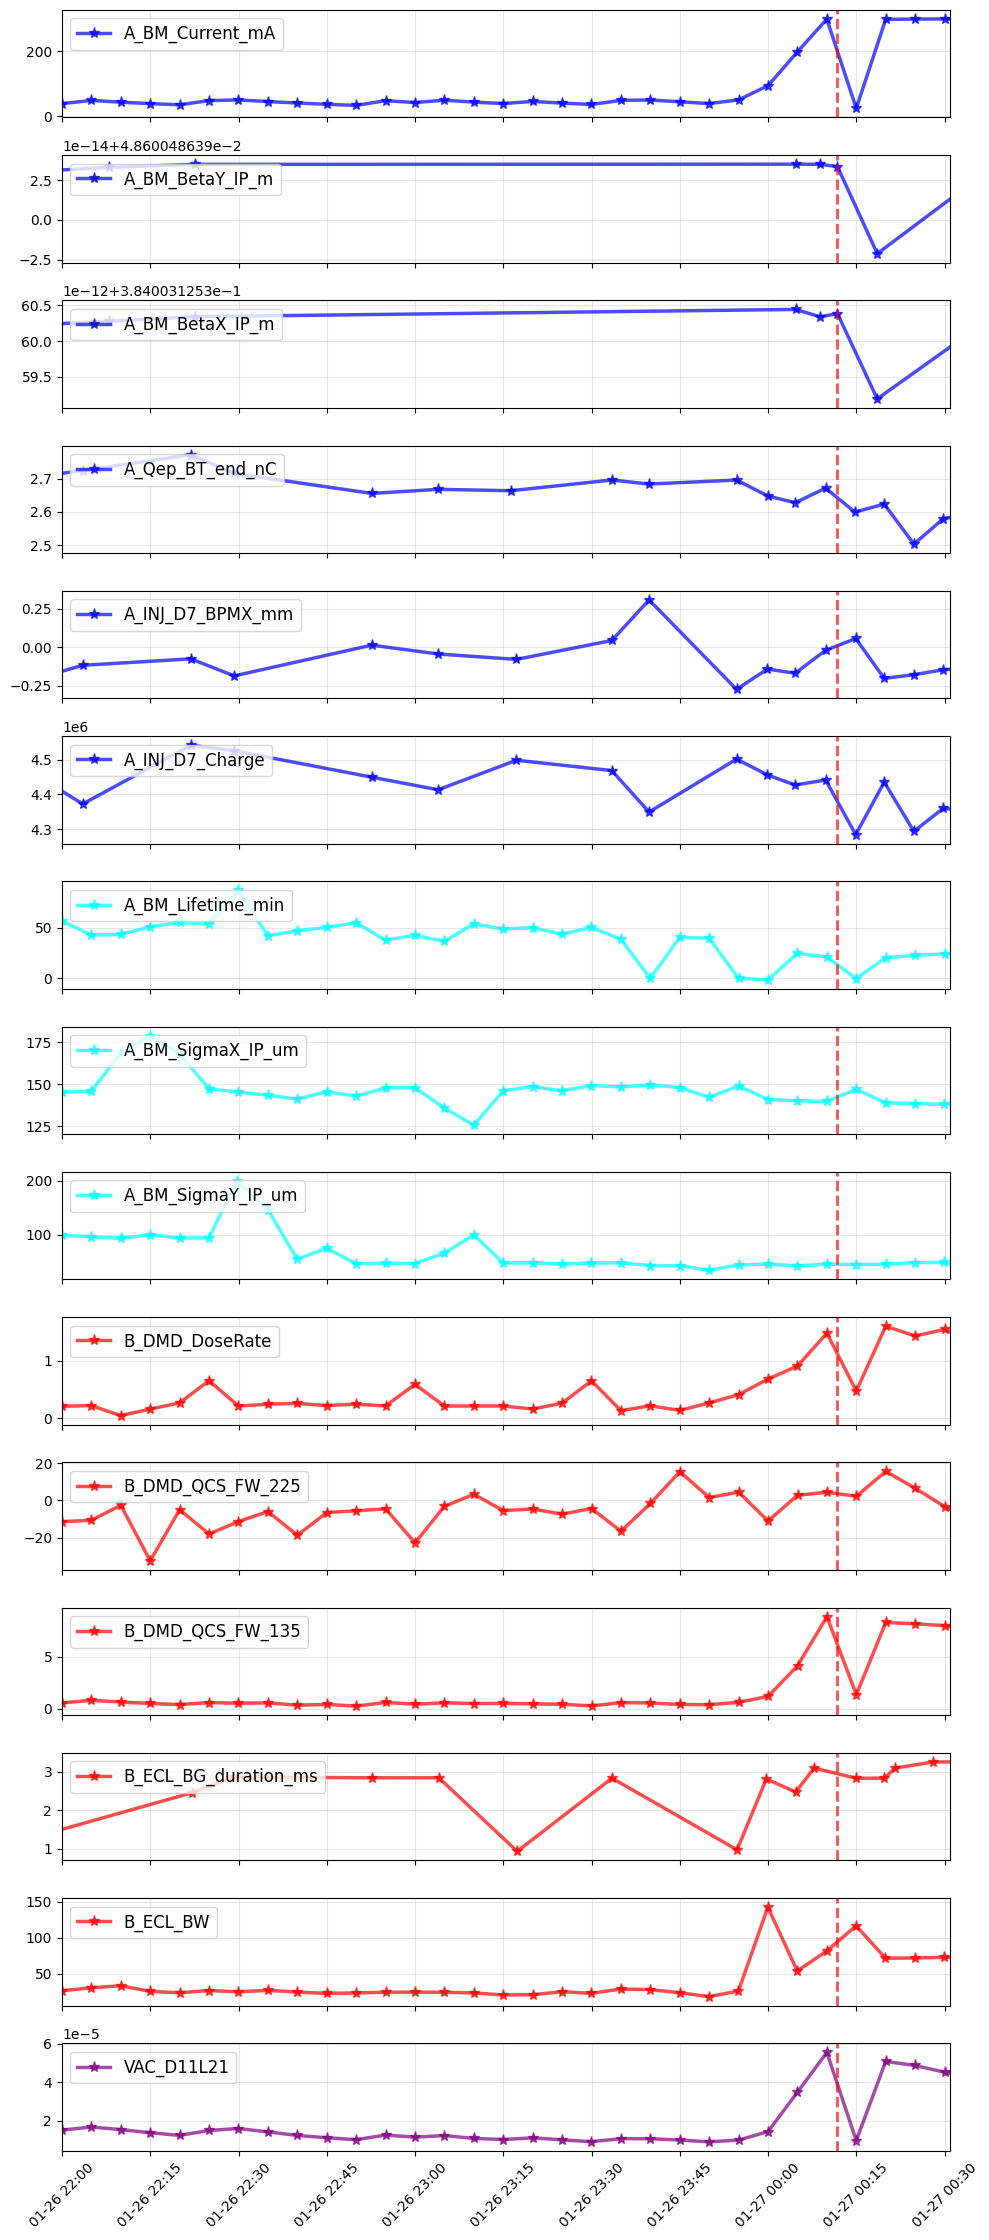

Plotted 15 variables from custom subset


In [104]:
# Define subset of variables to plot - edit this list!
subset_vars = [
    # "A_LUMI_30",
    # "A_LUMI_SP_30",
    "A_BM_Current_mA",
    "A_BM_BetaY_IP_m",
    "A_BM_BetaX_IP_m",
    # "A_BM_CapSigmaY_um",
    "A_Qep_BT_end_nC",
    "A_Qep_Linac_end_nC",
    # "A_INJ_Effi",
    # "A_INJ_Rep_ep_Hz",
    # "A_INJ_Kicker_Height_mm",
    # "A_INJ_Kicker_Jump",
    # "A_INJ_Septum_Pos_mm",
    # "A_INJ_Septum_Ang_mm",
    # "A_INJ_Phase",
    # "A_INJ_PosY_m",
    # "A_INJ_AngY_rad",
    "A_INJ_D7_BPMX_mm",
    "A_INJ_D7_MPBY_mm",
    "A_INJ_D7_Charge",
    # "A_D6V1_TOP_Head_Pos_Set",
    # "A_D6V1_TOP_Head_Pos_Meas",
    # "A_D6V1_BTM_Head_Pos_Set",
    # "A_D6V1_BTM_Head_Pos_Meas",
    # "A_D6V1_Upstrm_BPM_PosX",
    # "A_D6V1_Upstrm_BPM_PosY",
    # "A_D6V1_Downstrm_BPM_PosX",
    # "A_D6V1_Downstrm_BPM_PosY",
    # "A_BM_Inj_Rate_mAps",
    "A_BM_Lifetime_min",
    "A_BM_SigmaX_IP_um",
    "A_BM_SigmaY_IP_um",
    "B_DMD_DoseRate",
    "B_DMD_QCS_FW_225",
    "B_DMD_QCS_FW_135",
    # "B_CDC_Imax_uA",
    # "B_CDC_Iavg_uA",
    # "B_PMThits_Hz",
    # "B_PMThits_avg60s",
    "B_ECL_BG_duration_ms",
    "B_ECL_BW",
    # "VAC_D4L01",
    # "VAC_D4L02",
    # "VAC_D4L03",
    # "VAC_D4L04",
    # "VAC_D4L05",
    # "VAC_D4L06",
    # "VAC_D4L07",
    # "VAC_D4L08",
    # "VAC_D10L01",
    # "VAC_D10L02",
    # "VAC_D10L03",
    # "VAC_D10L04",
    # "VAC_D10L05",
    # "VAC_D10L06",
    # "VAC_D10L07",
    # "VAC_D10L08",
    # "VAC_D11L18",
    # "VAC_D11L19",
    # "VAC_D11L20",
    "VAC_D11L21",
    # "VAC_D11L22",
    # "VAC_D11L23",
    # "VAC_D11L24"
]
# Plot a custom subset of variables
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Find the corresponding dataframes and columns for each variable
subset_data = []
for var_name in subset_vars:
    # Search in each dataframe for a column with this friendly name
    for col in acc1_numeric_cols:
        if get_friendly_name(col) == var_name:
            subset_data.append({'df': acc_df1, 'col': col, 'friendly': var_name, 'color': 'blue'})
            break
    else:
        for col in acc2_numeric_cols:
            if get_friendly_name(col) == var_name:
                subset_data.append({'df': acc_df2, 'col': col, 'friendly': var_name, 'color': 'green'})
                break
        else:
            for col in acc3_numeric_cols:
                if get_friendly_name(col) == var_name:
                    subset_data.append({'df': acc_df3, 'col': col, 'friendly': var_name, 'color': 'cyan'})
                    break
            else:
                for col in belle2_numeric_cols:
                    if get_friendly_name(col) == var_name:
                        subset_data.append({'df': belle2_df, 'col': col, 'friendly': var_name, 'color': 'red'})
                        break
                else:
                    for col in vacuum_numeric_cols:
                        if get_friendly_name(col) == var_name:
                            subset_data.append({'df': vacuum_df, 'col': col, 'friendly': var_name, 'color': 'purple'})
                            break

# Create subplots
fig, axes = plt.subplots(len(subset_data), 1, figsize=(10, 1.5*len(subset_data)), sharex=True)
if len(subset_data) == 1:
    axes = [axes]

for i, item in enumerate(subset_data):
    df = item['df']
    col = item['col']
    friendly_name = item['friendly']
    color = item['color']
    
    # Remove NaNs but keep line connection through valid points
    valid_mask = df[col].notna()
    axes[i].plot(df.loc[valid_mask, 'Timestamp'], df.loc[valid_mask, col], 
                 marker='*', markersize=8, alpha=0.7, linestyle='-', linewidth=2.5, 
                 color=color, label=f'{friendly_name}')
    
    # Set y-limits based on visible data range
    mask = (df['Timestamp'] >= PLOT_START) & (df['Timestamp'] <= PLOT_END)
    if mask.any():
        y_data = df.loc[mask, col].dropna()
        if len(y_data) > 0:
            y_min, y_max = y_data.min(), y_data.max()
            y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
            axes[i].set_ylim(y_min - y_pad, y_max + y_pad)
    
    axes[i].legend(loc='upper left', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    if i < len(subset_data) - 1:
        axes[i].set_xlabel('')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes:
    ax.set_xlim(PLOT_START, PLOT_END)
    if EVENT_MARKER is not None:
        ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Event')

plt.xticks(rotation=45, fontsize=10)
plt.subplots_adjust(hspace=0.3)
plt.tight_layout()
plt.show()

print(f"Plotted {len(subset_data)} variables from custom subset")


In [ ]:
# Build event-aligned data (next numeric value after event) + photocurrent
events = [
    {"time": "20260128_025331", "photocurrent_mA": 2.2628},
    {"time": "20260128_134122", "photocurrent_mA": 1.4406},
    {"time": "20260128_190150", "photocurrent_mA": 2.8680},
    {"time": "20260128_205419", "photocurrent_mA": 1.7919},
    {"time": "20260128_212802", "photocurrent_mA": 2.3858},
    {"time": "20260129_101918", "photocurrent_mA": 3.0957},
]

def parse_event_time(time_str):
    date_str, time_part = time_str.split('_')[0], time_str.split('_')[1]
    return pd.to_datetime(f"{date_str} {time_part}", format="%Y%m%d %H%M%S")

def next_value_after_event(df, ts, col, prefix):
    if df is None or df.empty or col not in df.columns:
        return {f"{prefix}_{col}": np.nan, f"{prefix}_{col}__Timestamp": pd.NaT, f"{prefix}_{col}__time_delta_s": np.nan}
    df_sorted = df.sort_values('Timestamp').reset_index(drop=True)
    mask = (df_sorted['Timestamp'] >= ts) & (df_sorted[col].notna())
    if not mask.any():
        return {f"{prefix}_{col}": np.nan, f"{prefix}_{col}__Timestamp": pd.NaT, f"{prefix}_{col}__time_delta_s": np.nan}
    row = df_sorted.loc[mask].iloc[0]
    return {
        f"{prefix}_{col}": row[col],
        f"{prefix}_{col}__Timestamp": row['Timestamp'],
        f"{prefix}_{col}__time_delta_s": (row['Timestamp'] - ts).total_seconds()
    }

event_records = []
for ev in events:
    event_time = parse_event_time(ev["time"])
    record = {
        "event_time": event_time,
        "event_time_str": ev["time"],
        "photocurrent_mA": ev["photocurrent_mA"]
    }
    # For every numeric column in each file, grab the next available non-NaN value after the event
    for col in acc1_numeric_cols:
        record.update(next_value_after_event(acc_df1, event_time, col, "acc1"))
    for col in acc2_numeric_cols:
        record.update(next_value_after_event(acc_df2, event_time, col, "acc2"))
    for col in acc3_numeric_cols:
        record.update(next_value_after_event(acc_df3, event_time, col, "acc3"))
    for col in belle2_numeric_cols:
        record.update(next_value_after_event(belle2_df, event_time, col, "belle2"))
    for col in vacuum_numeric_cols:
        record.update(next_value_after_event(vacuum_df, event_time, col, "vacuum"))
    event_records.append(record)

event_values_df = pd.DataFrame(event_records)
event_photocurrent_mA = event_values_df["photocurrent_mA"].values
event_times = event_values_df["event_time"].values

print("Event-aligned values (next non-NaN after event for every PV column):")
display(event_values_df[["event_time_str", "event_time", "photocurrent_mA"]])
print(f"Total variables per event (excluding metadata): {event_values_df.shape[1] - 3}")


In [ ]:
# Correlate all PV values with photocurrent + heatmap (using absolute values)
meta_cols = {"event_time", "event_time_str", "photocurrent_mA"}
exclude_suffixes = ("__Timestamp", "__time_delta_s")
pv_cols = [
    c for c in event_values_df.columns
    if c not in meta_cols and not c.endswith(exclude_suffixes)
    and pd.api.types.is_numeric_dtype(event_values_df[c])
 ]

# Create a copy with absolute values for correlation calculation
event_values_abs = event_values_df[pv_cols + ["photocurrent_mA"]].abs()

corr_series = event_values_abs[pv_cols].corrwith(event_values_abs["photocurrent_mA"])
# Map column names to friendly names for display
friendly_col_names = {col: get_friendly_name_from_event_col(col) for col in pv_cols}
corr_df = corr_series.to_frame(name="corr_with_photocurrent")
corr_df.index = corr_df.index.map(lambda x: friendly_col_names.get(x, x))
corr_df = corr_df.sort_values(by="corr_with_photocurrent", ascending=False)

print(f"PV columns used for correlation: {len(pv_cols)}")
print("(Using absolute values of all variables)")
display(corr_df)

# Heatmap (single-column correlation view)
plt.figure(figsize=(6, max(6, len(corr_df) * 0.25)))
sns.heatmap(corr_df, cmap="coolwarm", center=0, cbar=True)
plt.title("Correlation with Photocurrent (absolute values)")
plt.tight_layout()
plt.show()


In [ ]:
# Plot PVs with strong correlation (>0.35) vs photocurrent (5 events) - normalized to peak
strong_corr_pv_cols = corr_df[corr_df["corr_with_photocurrent"] > 0.35].index.tolist()
if not strong_corr_pv_cols:
    print("No PV columns with correlation > 0.35.")
else:
    x_labels = event_values_df["event_time_str"].tolist()
    x = np.arange(len(x_labels))
    plt.figure(figsize=(12, 6))
    for friendly_col_name in strong_corr_pv_cols:
        # Get the original column name from corr_df
        orig_col_idx = [i for i, col in enumerate(pv_cols) if get_friendly_name_from_event_col(col) == friendly_col_name]
        if orig_col_idx:
            orig_col = pv_cols[orig_col_idx[0]]
            y = np.abs(event_values_df[orig_col].values.astype(float))  # Use absolute values
            y_peak = np.nanmax(y)
            if np.isfinite(y_peak) and y_peak != 0:
                y_norm = y / y_peak
            else:
                y_norm = np.full_like(y, np.nan, dtype=float)
            # Remove NaNs but keep line connection through valid points
            valid_mask = ~np.isnan(y_norm)
            x_valid = x[valid_mask]
            y_valid = y_norm[valid_mask]
            plt.plot(x_valid, y_valid, marker='o', linewidth=2.5, markersize=6, alpha=0.8, label=friendly_col_name)
    # Photocurrent (normalized to peak) with different marker
    pc = np.abs(event_values_df["photocurrent_mA"].values.astype(float))  # Use absolute values
    pc_peak = np.nanmax(pc)
    if np.isfinite(pc_peak) and pc_peak != 0:
        pc_norm = pc / pc_peak
    else:
        pc_norm = np.full_like(pc, np.nan, dtype=float)
    # Remove NaNs but keep line connection
    valid_mask_pc = ~np.isnan(pc_norm)
    x_valid_pc = x[valid_mask_pc]
    pc_valid = pc_norm[valid_mask_pc]
    plt.plot(x_valid_pc, pc_valid, marker='s', linewidth=3.0, markersize=8, alpha=0.9, color='black', label='photocurrent_mA')
    plt.xticks(x, x_labels, rotation=45, ha='right')
    plt.xlabel("Event time")
    plt.ylabel("Normalized value (peak = 1)")
    plt.title("Normalized PVs with correlation > 0.35 to photocurrent (5 events)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot PV values (corr > 0.35) vs photocurrent (x-axis) - normalized peaks
strong_corr_pv_cols = corr_df[corr_df["corr_with_photocurrent"] > 0.35].index.tolist()
if not strong_corr_pv_cols:
    print("No PV columns with correlation > 0.35.")
else:
    x = np.abs(event_values_df["photocurrent_mA"].values.astype(float))
    # Sort indices by photocurrent (small to large)
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]
    
    plt.figure(figsize=(12, 6))
    for friendly_col_name in strong_corr_pv_cols:
        # Get the original column name from corr_df
        orig_col_idx = [i for i, col in enumerate(pv_cols) if get_friendly_name_from_event_col(col) == friendly_col_name]
        if orig_col_idx:
            orig_col = pv_cols[orig_col_idx[0]]
            y = np.abs(event_values_df[orig_col].values.astype(float))  # Use absolute values
            y_peak = np.nanmax(y)
            if np.isfinite(y_peak) and y_peak != 0:
                y_norm = y / y_peak
            else:
                y_norm = np.full_like(y, np.nan, dtype=float)
            y_sorted = y_norm[sort_idx]
            # Remove NaNs but keep line connection through valid points
            valid_mask = ~np.isnan(y_sorted)
            x_plot = x_sorted[valid_mask]
            y_plot = y_sorted[valid_mask]
            plt.plot(x_plot, y_plot, marker='o', linewidth=2.5, markersize=6, alpha=0.85, label=friendly_col_name)
    plt.xlabel("|Photocurrent| (mA)")
    plt.ylabel("Normalized PV value (|peak| = 1)")
    plt.title("PVs with correlation > 0.35 vs |Photocurrent| (normalized peaks)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# # Plot all ACC data columns together
# fig, ax = plt.subplots(figsize=(16, 8))

# # Get all numeric columns (exclude Timestamp)
# acc_numeric_cols = acc_df1.select_dtypes(include=[np.number]).columns.tolist()

# # Plot each column
# for col in acc_numeric_cols:
#     ax.plot(acc_df1['Timestamp'], acc_df1[col], label=col, marker='o', markersize=3, alpha=0.7)

# ax.set_xlabel('Time', fontsize=12)
# ax.set_ylabel('Values', fontsize=12)
# ax.set_title('ACC Data - All Columns', fontsize=14, fontweight='bold')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# ax.grid(True, alpha=0.3)
# ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# print(f"Plotted {len(acc_numeric_cols)} columns from ACC data")

# # Plot all Belle2 data columns together
# fig, ax = plt.subplots(figsize=(16, 8))

# # Get all numeric columns (exclude Timestamp)
# belle2_numeric_cols = belle2_df.select_dtypes(include=[np.number]).columns.tolist()

# # Plot each column
# for col in belle2_numeric_cols:
#     ax.plot(belle2_df['Timestamp'], belle2_df[col], label=col, marker='o', markersize=3, alpha=0.7)

# ax.set_xlabel('Time', fontsize=12)
# ax.set_ylabel('Values', fontsize=12)
# ax.set_title('Belle2 Data - All Columns', fontsize=14, fontweight='bold')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# ax.grid(True, alpha=0.3)
# ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# print(f"Plotted {len(belle2_numeric_cols)} columns from Belle2 data")

# # Plot all Vacuum data columns together
# fig, ax = plt.subplots(figsize=(16, 8))

# # Get all numeric columns (exclude Timestamp)
# vacuum_numeric_cols = vacuum_df.select_dtypes(include=[np.number]).columns.tolist()

# # Plot each column
# for col in vacuum_numeric_cols:
#     ax.plot(vacuum_df['Timestamp'], vacuum_df[col], label=col, marker='o', markersize=3, alpha=0.7)

# ax.set_xlabel('Time', fontsize=12)
# ax.set_ylabel('Values', fontsize=12)
# ax.set_title('Vacuum Data - All Columns', fontsize=14, fontweight='bold')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# ax.grid(True, alpha=0.3)
# ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# print(f"Plotted {len(vacuum_numeric_cols)} columns from Vacuum data")

In [ ]:
# # Create correlation matrix for all numeric columns
# # First, let's see how much data we have for each column
# print("Data availability for each numeric column:")
# for col in all_numeric_columns:
#     if col in all_data.columns:
#         non_na_count = all_data[col].notna().sum()
#         total_count = len(all_data)
#         percentage = (non_na_count / total_count) * 100
#         print(f"{col}: {non_na_count}/{total_count} ({percentage:.1f}%)")

# # Create a subset with only numeric columns for correlation
# numeric_data = all_data[all_numeric_columns].copy()

# # Calculate correlation matrix (will handle NaN by excluding them pairwise)
# correlation_matrix = numeric_data.corr(method='pearson', min_periods=10)

# print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")
# print(f"Number of valid correlations: {correlation_matrix.notna().sum().sum()}")

In [ ]:
# # Split combined ACC columns into two groups (14 and 13) and plot each with no vertical spacing
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# import numpy as np

# all_acc_cols = list(acc1_numeric_cols) + list(acc2_numeric_cols) + list(acc3_numeric_cols)
# group1 = all_acc_cols[:14]
# group2 = all_acc_cols[14:]

# def plot_acc_group(cols, fname, figsize_width=10, height_per_trace=1, legend_fs=12, tick_fs=10):
#     n = len(cols)
#     fig, axes = plt.subplots(n, 1, figsize=(figsize_width, height_per_trace * n), sharex=True)
#     axes = np.atleast_1d(axes)
#     for i, col in enumerate(cols):
#         if col in acc_df1.columns:
#             src_df = acc_df1
#         elif col in acc_df2.columns:
#             src_df = acc_df2
#         elif col in acc_df3.columns:
#             src_df = acc_df3
#         else:
#             continue
#         friendly_name = get_friendly_name(col)
#         # Remove NaNs but keep line connection through valid points
#         valid_mask = src_df[col].notna()
#         axes[i].plot(src_df.loc[valid_mask, 'Timestamp'], src_df.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-',
#                      label=f'{friendly_name}')
#         # Set y-limits based on visible data range
#         mask = (src_df['Timestamp'] >= PLOT_START) & (src_df['Timestamp'] <= PLOT_END)
#         if mask.any():
#             y_data = src_df.loc[mask, col].dropna()
#             if len(y_data) > 0:
#                 y_min, y_max = y_data.min(), y_data.max()
#                 y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
#                 axes[i].set_ylim(y_min - y_pad, y_max + y_pad)
#         axes[i].legend(loc='upper left', fontsize=legend_fs)
#         axes[i].grid(True, alpha=0.3)
#         if i < n - 1:
#             axes[i].tick_params(labelbottom=False)
#     axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
#     for ax in axes:
#         ax.set_xlim(PLOT_START, PLOT_END)
#         if EVENT_MARKER is not None:
#             ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7)
#     plt.xticks(rotation=45, fontsize=tick_fs)
#     plt.subplots_adjust(hspace=0)   # remove vertical spacing
#     plt.tight_layout()
#     plt.savefig(fname, dpi=300, bbox_inches='tight')
#     plt.show()

# # plot_acc_group(group1, 'acc_group1.png', figsize_width=10, height_per_trace=1)
# # plot_acc_group(group2, 'acc_group2.png', figsize_width=10, height_per_trace=1)
# # print("Saved acc_group1_14.png and acc_group2_13.png")

# # make vacuum subplot taller using height ratios (paste over your fig3/axes3 creation & vacuum+Belle2 plotting)
# import numpy as np

# total_subplots = 1 + len(belle2_numeric_cols)
# height_ratios = [3] + [1] * len(belle2_numeric_cols)  # vacuum subplot 3x taller

# fig3, axes3 = plt.subplots(
#     total_subplots, 1,
#     figsize=(10, 1*total_subplots),
#     sharex=True,
#     gridspec_kw={'height_ratios': height_ratios}
# )
# axes3 = np.atleast_1d(axes3)

# # Vacuum on first subplot (all traces)
# for col in vacuum_numeric_cols:
#     friendly_name = get_friendly_name(col)
#     # Remove NaNs but keep line connection through valid points
#     valid_mask = vacuum_df[col].notna()
#     axes3[0].plot(vacuum_df.loc[valid_mask, 'Timestamp'], vacuum_df.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-', color='blue',label=f'{friendly_name}')
# # Set y-limits based on visible data range for vacuum
# mask = (vacuum_df['Timestamp'] >= PLOT_START) & (vacuum_df['Timestamp'] <= PLOT_END)
# if mask.any():
#     y_data_list = []
#     for col in vacuum_numeric_cols:
#         y_data = vacuum_df.loc[mask, col].dropna()
#         if len(y_data) > 0:
#             y_data_list.extend(y_data.tolist())
#     if y_data_list:
#         y_min, y_max = min(y_data_list), max(y_data_list)
#         y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
#         axes3[0].set_ylim(y_min - y_pad, y_max + y_pad)
# # axes3[0].legend(loc='upper left', fontsize=10)
# axes3[0].grid(True, alpha=0.3)
# axes3[0].tick_params(labelbottom=False)

# # Belle2 on remaining subplots
# for i, col in enumerate(belle2_numeric_cols):
#     idx = i + 1
#     friendly_name = get_friendly_name(col)
#     # Remove NaNs but keep line connection through valid points
#     valid_mask = belle2_df[col].notna()
#     axes3[idx].plot(belle2_df.loc[valid_mask, 'Timestamp'], belle2_df.loc[valid_mask, col], marker='*', markersize=5, alpha=0.7, linestyle='-', color='blue', label=f'{friendly_name}')
#     # Set y-limits based on visible data range
#     mask = (belle2_df['Timestamp'] >= PLOT_START) & (belle2_df['Timestamp'] <= PLOT_END)
#     if mask.any():
#         y_data = belle2_df.loc[mask, col].dropna()
#         if len(y_data) > 0:
#             y_min, y_max = y_data.min(), y_data.max()
#             y_pad = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_max) * 0.1
#             axes3[idx].set_ylim(y_min - y_pad, y_max + y_pad)
#     # axes3[idx].set_ylabel('Value', fontsize=12)
#     axes3[idx].legend(loc='upper left', fontsize=10)
#     axes3[idx].grid(True, alpha=0.3)
#     if idx < len(axes3) - 1:
#         axes3[idx].tick_params(labelbottom=False)

# axes3[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
# for ax in axes3:
#     ax.set_xlim(PLOT_START, PLOT_END)
#     if EVENT_MARKER is not None:
#         ax.axvline(EVENT_MARKER, color='red', linestyle='--', linewidth=2, alpha=0.7)

# plt.subplots_adjust(hspace=0)
# plt.savefig('belle2_plots.png', dpi=300, bbox_inches='tight')
# plt.show()
